# Triangular Nonlinear Triple Mass Spring 2D: Results Visualization

This notebook evaluates and visualizes trained models for the triangular nonlinear triple mass spring system in 2D.

**Capabilities:**
1. Error metrics over time (mean ± std and percentiles)
2. 2D trajectory visualizations
3. 1D trajectory comparisons along specific axes
4. Cumulative error analysis
5. Observed vs unobserved error comparison
6. Energy conservation analysis

## 1. Setup and Imports

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import json

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from utilities import Params, load_model, integrate_vector_field
from models import HamiltonianNN, NeuralODE
from vector_fields import (
    vector_field_triangular_nonlinear_mass_spring_2d,
    vector_field_hnn_potenergy,
    vector_field_hnn_totenergy,
    vector_field_node_phys,
    vector_field_node_vanilla,
)

In [2]:
# Initialize RNG
key = jax.random.PRNGKey(42)

## 2. Plotting Configuration

In [3]:
# Font settings
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'sans-serif'

# Color palette
COLORS = {
    "hnn_pot": "#2160B3",      # Blue
    "hnn_tot": "#74c6ec",      # Cyan  
    "node_phys": "#f0c37c",    # Red
    "node_vanilla": "#D27146", # Yellow
    "true": "#333333",         # Grey
}

LABELS = {
    "hnn_pot": "NHODE$_{\mathrm{pot,rel}}$",
    "hnn_tot": "NHODE$_{\mathrm{tot,rel}}$",
    "node_phys": "NODE$_{\mathrm{phys,rel}}$",
    "node_vanilla": "NODE$_{\mathrm{vanilla,rel}}$",
    "true": "Ground Truth",
}

## 3. Configuration & System Parameters

In [4]:
# Simulation parameters
T_FINAL = 20.0          # Final time
N_TIMESTEPS = 2001      # Number of timesteps

# Observed and unobserved dimensions
# State: [qx0,qy0,qx1,qy1,qx2,qy2, px0,py0,px1,py1,px2,py2]
# Observe masses 0 and 1 (both position and momentum)
OBSERVED_DIMS = [0, 1, 2, 3, 6, 7, 8, 9]
UNOBSERVED_DIMS = [4, 5, 10, 11]

# System parameters (must match training)
system_params = Params(
    m0=1.0,
    m1=1.0, 
    m2=1.0,
    k01=0.05,
    k12=0.05,
    k02=0.05,
    L01=0.9,
    L12=0.9,
    L02=0.9,
)

# Test data configuration
N_TEST_TRAJECTORIES = 10  # Number of initial conditions to test

# Checkpoint directory
CKPT_DIR = Path("checkpoints/spring_constant_0-05")

## 4. Helper Functions

### 4.1 Initial Condition Sampling

In [5]:
def zero_total_momentum(v, masses):
    """
    Adjust velocities to ensure zero center-of-mass momentum.
    """
    M = jnp.sum(masses)
    V_cm = jnp.tensordot(masses, v, axes=(0, -2)) / M
    return v - V_cm[..., None, :]

In [6]:
def sample_initial_conditions(key: jax.random.PRNGKey, n_samples: int, system_params: Params):
    """
    Sample initial conditions for the 2D triangular three-mass-spring system.
    
    State format: [qx0,qy0,qx1,qy1,qx2,qy2, px0,py0,px1,py1,px2,py2]
    
    Creates triangular configurations with small random perturbations.
    
    Returns
    -------
    y0s : array [n_samples, 12]
        Initial conditions
    """
    keys = jax.random.split(key, 4)
    
    # Create equilateral triangle base configuration
    # Mass 0 at top, masses 1 and 2 at bottom left and right
    # base_x0 = 0.5
    # base_y0 = 1.2
    # base_x1 = 0.2
    # base_y1 = 0.3
    # base_x2 = 0.8
    # base_y2 = 0.3
    
    # # Add small random perturbations to positions
    # perturbation_scale = 0.1

    
    # qx0 = base_x0 + jax.random.uniform(keys[0], (n_samples,), minval=-perturbation_scale, maxval=perturbation_scale)
    # qy0 = base_y0 + jax.random.uniform(keys[0], (n_samples,), minval=-perturbation_scale, maxval=perturbation_scale)
    
    # qx1 = base_x1 + jax.random.uniform(keys[1], (n_samples,), minval=-perturbation_scale, maxval=perturbation_scale)
    # qy1 = base_y1 + jax.random.uniform(keys[1], (n_samples,), minval=-perturbation_scale, maxval=perturbation_scale)
    
    # qx2 = base_x2 + jax.random.uniform(keys[2], (n_samples,), minval=-perturbation_scale, maxval=perturbation_scale)
    # qy2 = base_y2 + jax.random.uniform(keys[2], (n_samples,), minval=-perturbation_scale, maxval=perturbation_scale)
    

        # Mass 0: top center
    qx0 = jax.random.uniform(keys[0], (n_samples,), minval=0.3, maxval=0.7)
    qy0 = jax.random.uniform(keys[0], (n_samples,), minval=1.0, maxval=1.4)
    
    # Mass 1: bottom left
    qx1 = jax.random.uniform(keys[1], (n_samples,), minval=0.1, maxval=0.4)
    qy1 = jax.random.uniform(keys[1], (n_samples,), minval=0.1, maxval=0.5)
    
    # Mass 2: bottom right
    qx2 = jax.random.uniform(keys[2], (n_samples,), minval=0.6, maxval=0.9)
    qy2 = jax.random.uniform(keys[2], (n_samples,), minval=0.1, maxval=0.5)

    # Sample small random velocities
    #velocity_scale = 0.2
    #px = jax.random.uniform(keys[3], (n_samples, 3), minval=-velocity_scale, maxval=velocity_scale)
    #py = jax.random.uniform(keys[3], (n_samples, 3), minval=-velocity_scale, maxval=velocity_scale)
    
    # Convert velocities to momenta
    masses = jnp.array([system_params.m0, system_params.m1, system_params.m2])
    # px = px * masses[None, :]
    # py = py * masses[None, :]

    v = jax.random.uniform(keys[3], (n_samples, 6), minval=-0.3, maxval=0.3)
    for i in range(n_samples):
        v = v.at[i, :].set(
            zero_total_momentum(v[i, :].reshape(3, 2), masses).reshape(-1)
        )
    print(v.shape)
    print(masses.shape)
    p = (v.reshape(n_samples, 3, 2) * masses[None, :, None]).reshape(n_samples, 6)
    
    # Assemble state vector [n_samples, 12]
    q = jnp.stack([qx0, qy0, qx1, qy1, qx2, qy2], axis=-1)
    #p = jnp.stack([px[:, 0], py[:, 0], px[:, 1], py[:, 1], px[:, 2], py[:, 2]], axis=-1)
    
    return jnp.concatenate([q, p], axis=-1)

### 4.2 Model Loading and Simulation

In [7]:
def load_metadata(seed_dir: Path, method: str) -> dict:
    """
    Load metadata JSON file from checkpoint directory.
    
    Parameters
    ----------
    seed_dir : Path
        Checkpoint directory containing metadata file
    method : str
        Method name (used in filename)
        
    Returns
    -------
    metadata : dict
        Model configuration and training metadata
    """
    if method.startswith("hnn_pot"):
        method_key = "hnn_pot"
    elif method.startswith("hnn_tot"):
        method_key = "hnn_tot"
    elif method.startswith("node_phys"):
        method_key = "node_phys"
    elif method.startswith("node_vanilla"):
        method_key = "node_vanilla"
    else:
        method_key = method

    metadata_path = seed_dir / f"three_mass_spring_{method_key}_metadata.json"
    if metadata_path.exists():
        with open(metadata_path, 'r') as f:
            return json.load(f)
    return None


def get_model_skeleton(method: str, key: jax.random.PRNGKey, metadata: dict = None):
    """
    Create a model skeleton for loading saved weights.
    
    Parameters
    ----------
    method : str
        One of: 'hnn_pot', 'hnn_tot', 'node_phys', 'node_vanilla'
    key : PRNGKey
        Random key for initialization
    metadata : dict or None
        Metadata dictionary with architecture parameters.
        If None, uses default parameters.
        
    Returns
    -------
    model_like : Model
        Empty model with correct architecture
    """
    # Get architecture parameters from metadata or use defaults
    if metadata is not None:
        hidden_dim = metadata.get('hidden_dim', 128)
        depth = metadata.get('depth', 4)
        relative_distances = metadata.get('relative_distances', True)
    else:
        # Default fallback values
        hidden_dim = 128
        depth = 4
        relative_distances = True
    
    depth = 3 #FIXME this is just temporarily since all models were triained with depth=3 by mistake

    # Ensure relative_distances is a Python bool, not array
    if hasattr(relative_distances, 'item'):
        relative_distances = bool(relative_distances.item())
    else:
        relative_distances = bool(relative_distances)
    
    # Extract base method type
    if method.startswith("hnn_pot"): 
        method_type = "hnn_pot"
        input_dim = 6  # positions only
    elif method.startswith("hnn_tot"):
        method_type = "hnn_tot"
        input_dim = 12  # full state
    elif method.startswith("node_phys"):
        method_type = "node_phys"
        input_dim = 12  # full state
        output_dim = 6  # predicts dp/dt
    elif method.startswith("node_vanilla"):
        method_type = "node_vanilla"
        input_dim = 12  # full state
        output_dim = 12  # predicts dy/dt
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Create model skeleton
    if method_type in ["hnn_pot", "hnn_tot"]:
        return HamiltonianNN(
            input_dim=input_dim,
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )
    elif method_type == "node_phys":
        return NeuralODE(
            input_dim=input_dim,
            output_dim=output_dim,
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )
    elif method_type == "node_vanilla":
        return NeuralODE(
            input_dim=input_dim,
            output_dim=output_dim,
            key=key, 
            hidden_dim=hidden_dim, 
            depth=depth,
            relative_distances=relative_distances
        )


def get_vector_field(method: str):
    """
    Get the appropriate vector field function for a method.
    """
    vector_fields = {
        "hnn_pot_rel": vector_field_hnn_potenergy,
        "hnn_pot_abs": vector_field_hnn_potenergy,
        "hnn_pot": vector_field_hnn_potenergy,
        "hnn_tot_rel": vector_field_hnn_totenergy,
        "hnn_tot_abs": vector_field_hnn_totenergy,
        "hnn_tot": vector_field_hnn_totenergy,
        "node_phys": vector_field_node_phys,
        "node_vanilla": vector_field_node_vanilla,
        "true": vector_field_triangular_nonlinear_mass_spring_2d,
    }
    return vector_fields[method]


def discover_model_checkpoints(ckpt_dir: Path) -> Dict[str, List[Path]]:
    """
    Discover all model checkpoints organized by method and seed.
    
    Expected structure:
        checkpoints/
            method_name/
                seed_0/
                    three_mass_spring_method_name_model.eqx
                seed_1/
                    ...
    
    Returns
    -------
    method_to_paths : Dict[str, List[Path]]
        Mapping from method name to list of checkpoint directories
    """
    method_to_paths = {}
    
    for method_dir in sorted(ckpt_dir.iterdir()):
        if not method_dir.is_dir() or method_dir.name.startswith((".", "old", "keras", "spring_constant")):
            continue
            
        method_name = method_dir.name
        seed_dirs = sorted([d for d in method_dir.iterdir() 
                          if d.is_dir() and d.name.startswith("seed")])
        
        if seed_dirs:
            method_to_paths[method_name] = seed_dirs
    
    return method_to_paths

### 4.3 Error Metrics

In [8]:
@dataclass
class ErrorMetrics:
    """
    Container for error statistics across seeds and trajectories.
    
    All arrays have shape [n_timesteps].
    Cumulative metrics are scalars aggregated over time.
    """
    method: str
    
    # Time-dependent statistics
    mean_t: np.ndarray       # Mean error at each timestep
    std_t: np.ndarray        # Std error at each timestep
    median_t: np.ndarray     # Median error at each timestep
    p05_t: np.ndarray        # 5th percentile at each timestep
    p95_t: np.ndarray        # 95th percentile at each timestep
    
    mean_observed_t: np.ndarray       # Mean error for observed dimensions at each timestep
    mean_unobserved_t: np.ndarray     # Mean error for unobserved dimensions at each timestep
    median_observed_t: np.ndarray     # Median error for observed dimensions at each timestep
    median_unobserved_t: np.ndarray   # Median error for unobserved dimensions at each timestep
  
    # Cumulative statistics (scalar)
    cum_mean: float          # Mean of trajectory-averaged errors
    cum_std: float           # Std of trajectory-averaged errors
    cum_median: float        # Median of trajectory-averaged errors
    cum_p05: float           # 5th percentile of trajectory-averaged errors
    cum_p95: float           # 95th percentile of trajectory-averaged errors


def compute_mse(pred: jnp.ndarray, true: jnp.ndarray, dims: Optional[jnp.ndarray] = None) -> jnp.ndarray:
    """
    Compute mean squared error.
    
    Parameters
    ----------
    pred, true : array [..., T, D]
        Predictions and ground truth
    dims : array or None
        Indices of dimensions to evaluate. If None, use all dimensions.
        
    Returns
    -------
    mse : array [..., T]
        MSE over spatial dimensions at each timestep
    """
    if dims is not None:
        pred = pred[..., dims]
        true = true[..., dims]
    return jnp.mean((pred - true) ** 2, axis=-1)

## 5. Core Evaluation Function

In [9]:
def evaluate_method(
    method: str,
    seed_dirs: List[Path],
    y0_batch: jnp.ndarray,
    true_trajectories: jnp.ndarray,
    timesteps: jnp.ndarray,
    system_params: Params,
    eval_dims: Optional[jnp.ndarray] = None,
    key: Optional[jax.random.PRNGKey] = None,
) -> Tuple[ErrorMetrics, Dict]:
    """
    Evaluate a method across multiple seeds and initial conditions.
    
    Parameters
    ----------
    method : str
        Method name (e.g., 'hnn_pot', 'node_vanilla')
    seed_dirs : List[Path]
        List of checkpoint directories for different seeds
    y0_batch : array [n_ic, D]
        Initial conditions
    true_trajectories : array [n_ic, T, D]
        Ground truth trajectories
    timesteps : array [T]
        Time points
    system_params : Params
        System parameters
    eval_dims : array or None
        Dimensions to evaluate error on (None = all dimensions)
    key : PRNGKey or None
        Random key for model initialization
        
    Returns
    -------
    metrics : ErrorMetrics
        Error statistics
    predictions : Dict
        Dictionary containing:
            - 'all_predictions': array [n_seeds, n_ic, T, D]
            - 'mean_prediction': array [n_ic, T, D]
            - 'std_prediction': array [n_ic, T, D]
    """
    if key is None:
        key = jax.random.PRNGKey(0)
    
    n_ic, T, D = true_trajectories.shape
    n_seeds = len(seed_dirs)
    
    # Get vector field
    vector_field = get_vector_field(method)
    
    # Create integrator
    integrator = integrate_vector_field(timesteps, term=vector_field)
    
    # Load models and run predictions
    all_predictions = []
    
    for seed_dir in seed_dirs:
        
        # Load metadata to get exact architecture
        metadata = load_metadata(seed_dir, method)

        # Create model skeleton
        key, subkey = jax.random.split(key)
        model_skeleton = get_model_skeleton(method, subkey, metadata=metadata)

        model, aux = load_model(
            model_name=f"three_mass_spring_{method}",
            ckpt_dir=seed_dir,
            model_like=model_skeleton,
            aux_like={"system_params": system_params},
        )

        # Run simulation
        pred = integrator(model, system_params, y0_batch)  # [n_ic, T, D]
        all_predictions.append(pred)

    # Stack predictions: [n_seeds, n_ic, T, D]
    all_predictions = jnp.stack(all_predictions, axis=0)    
    
    # Compute errors for each (seed, ic) pair: [n_seeds, n_ic, T]
    errors = compute_mse(all_predictions, true_trajectories[None, ...], dims=eval_dims)
    
    errors_observed = compute_mse(all_predictions, true_trajectories[None, ...], dims=OBSERVED_DIMS)
    errors_unobserved = compute_mse(all_predictions, true_trajectories[None, ...], dims=UNOBSERVED_DIMS)

    # Flatten seeds and ICs: [n_seeds * n_ic, T]
    errors_flat = errors.reshape(-1, T)
    
    errors_observed_flat = errors_observed.reshape(-1, T)
    errors_unobserved_flat = errors_unobserved.reshape(-1, T)
  
    # Time-dependent statistics
    mean_t = np.asarray(jnp.mean(errors_flat, axis=0))
    std_t = np.asarray(jnp.std(errors_flat, axis=0))
    median_t = np.asarray(jnp.median(errors_flat, axis=0))
    p05_t = np.asarray(jnp.percentile(errors_flat, 5.0, axis=0))
    p95_t = np.asarray(jnp.percentile(errors_flat, 95.0, axis=0))
    
    mean_observed_t = jnp.asarray(jnp.mean(errors_observed_flat, axis=0))
    mean_unobserved_t = jnp.asarray(jnp.mean(errors_unobserved_flat, axis=0))
    median_observed_t = jnp.asarray(jnp.median(errors_observed_flat, axis=0))
    median_unobserved_t = jnp.asarray(jnp.median(errors_unobserved_flat, axis=0))
    
    # Cumulative statistics (average error over entire trajectory for each sample)
    cum_errors = jnp.mean(errors_flat, axis=1)  # [n_seeds * n_ic]
    cum_mean = float(jnp.mean(cum_errors))
    cum_std = float(jnp.std(cum_errors))
    cum_median = float(jnp.median(cum_errors))
    cum_p05 = float(jnp.percentile(cum_errors, 5.0))
    cum_p95 = float(jnp.percentile(cum_errors, 95.0))
    
    metrics = ErrorMetrics(
        method=method,
        mean_t=mean_t,
        std_t=std_t,
        median_t=median_t,
        p05_t=p05_t,
        p95_t=p95_t,
        mean_observed_t=mean_observed_t,
        mean_unobserved_t=mean_unobserved_t,
        median_observed_t=median_observed_t,
        median_unobserved_t=median_unobserved_t,
        cum_mean=cum_mean,
        cum_std=cum_std,
        cum_median=cum_median,
        cum_p05=cum_p05,
        cum_p95=cum_p95,
    )   

    mean_prediction = np.asarray(jnp.mean(all_predictions, axis=0))  # [n_ic, T, D]
    std_prediction = np.asarray(jnp.std(all_predictions, axis=0))    # [n_ic, T, D]

    trajectories = {
        'all_predictions': all_predictions,
        'mean_prediction': mean_prediction,
        'std_prediction': std_prediction,
        'all_true': true_trajectories,
    }
    
    return metrics, trajectories

## 6. Plotting Functions

### 6.1 Training Loss Visualization

In [10]:
def load_training_losses(seed_dirs: List[Path], method: str) -> Dict[str, np.ndarray]:
    """
    Load training and validation losses from checkpoint directories.
    
    Parameters
    ----------
    seed_dirs : List[Path]
        List of checkpoint directories for different seeds
    method : str
        Method name (used in filename)
        
    Returns
    -------
    losses_dict : Dict[str, np.ndarray]
        Dictionary containing:
            - 'train_losses': array [n_seeds, n_epochs]
            - 'val_losses': array [n_seeds, n_epochs]
            - 'epochs': array [n_epochs]
    """
    all_train_losses = []
    all_val_losses = []
    epochs = None

    if method.startswith("hnn_pot"):
        method_key = "hnn_pot"
    elif method.startswith("hnn_tot"):
        method_key = "hnn_tot"
    elif method.startswith("node_phys"):
        method_key = "node_phys"
    elif method.startswith("node_vanilla"):
        method_key = "node_vanilla"
    else:
        method_key = method
    
    for seed_dir in seed_dirs:
        loss_path = seed_dir / f"{method_key}_losses.npz"
        
        if loss_path.exists():
            data = np.load(loss_path)
            train_loss = data['train']
            val_loss = data['val']
            
            all_train_losses.append(train_loss)
            all_val_losses.append(val_loss)
            
            if epochs is None:
                epochs = np.arange(len(train_loss))
        else:
            print(f"Warning: Loss file not found at {loss_path}")
    
    if all_train_losses:
        return {
            'train_losses': np.array(all_train_losses),
            'val_losses': np.array(all_val_losses),
            'epochs': epochs,
        }
    else:
        return None


def plot_training_losses(
    method_to_paths: Dict[str, List[Path]],
    figsize: Tuple[float, float] = (14, 5),
    log_scale: bool = False,
    save_path: Optional[Path] = None,
):
    """
    Plot average training and validation losses across seeds for each method.
    
    Parameters
    ----------
    method_to_paths : Dict[str, List[Path]]
        Mapping from method name to list of checkpoint directories
    figsize : tuple
        Figure size
    log_scale : bool
        Use log scale for y-axis
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for method, seed_dirs in method_to_paths.items():
        losses = load_training_losses(seed_dirs, method)
        
        if losses is None:
            print(f"No loss data available for {method}")
            continue
        
        epochs = losses['epochs']
        train_losses = losses['train_losses']
        val_losses = losses['val_losses']
        
        # Compute statistics across seeds
        train_mean = np.mean(train_losses, axis=0)
        train_std = np.std(train_losses, axis=0)
        val_mean = np.mean(val_losses, axis=0)
        val_std = np.std(val_losses, axis=0)
        
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        # Plot training loss
        axes[0].plot(epochs, train_mean, label=label, color=color, linewidth=2)
        axes[0].fill_between(epochs, train_mean - train_std, train_mean + train_std,
                           alpha=0.2, color=color)
        
        # Plot validation loss
        axes[1].plot(epochs, val_mean, label=label, color=color, linewidth=2)
        axes[1].fill_between(epochs, val_mean - val_std, val_mean + val_std,
                           alpha=0.2, color=color)
    
    # Configure training loss plot
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training Loss')
    axes[0].set_title('Training Loss Over Epochs')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Configure validation loss plot
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Loss')
    axes[1].set_title('Validation Loss Over Epochs')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    if log_scale:
        axes[0].set_yscale('log')
        axes[1].set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def print_final_losses(method_to_paths: Dict[str, List[Path]]):
    """
    Print final training and validation losses for each method.
    """
    print("\n" + "="*70)
    print("FINAL TRAINING/VALIDATION LOSSES")
    print("="*70)
    print(f"{'Method':<25} {'Train Loss':<20} {'Val Loss':<20}")
    print("-"*70)
    
    for method, seed_dirs in method_to_paths.items():
        losses = load_training_losses(seed_dirs, method)
        
        if losses is None:
            continue
        
        train_losses = losses['train_losses'][:, -1]  # Last epoch
        val_losses = losses['val_losses'][:, -1]
        
        train_mean = np.mean(train_losses)
        train_std = np.std(train_losses)
        val_mean = np.mean(val_losses)
        val_std = np.std(val_losses)
        
        label = LABELS.get(method, method)
        train_str = f"{train_mean:.6e} ± {train_std:.6e}"
        val_str = f"{val_mean:.6e} ± {val_std:.6e}"
        
        print(f"{label:<25} {train_str:<20} {val_str:<20}")
    
    print("="*70 + "\n")

### 6.2 Error Over Time

In [11]:
def plot_error_over_time(
    metrics_list: Dict[str, ErrorMetrics],
    timesteps: np.ndarray,
    use_median: bool = True,
    log_scale: bool = False,
    figsize: Tuple[float, float] = (10, 6),
    fontsize: Optional[int] = 14,
    save_path: Optional[Path] = None,
):
    """
    Plot error over time with percentile bands.
    
    Parameters
    ----------
    metrics_list : List[ErrorMetrics]
        List of error metrics for each method
    timesteps : array [T]
        Time points
    use_median : bool
        If True, plot median with 5-95% band. If False, plot mean with ±std band.
    log_scale : bool
        Use log scale for y-axis
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for method, metrics in metrics_list.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        if use_median:
            ax.plot(timesteps, metrics.median_t, label=label, color=color, linewidth=2)
            ax.fill_between(timesteps, metrics.p05_t, metrics.p95_t, alpha=0.2, color=color)
        else:
            ax.plot(timesteps, metrics.mean_t, label=label, color=color, linewidth=2)
            ax.fill_between(timesteps, metrics.mean_t - metrics.std_t, metrics.mean_t + metrics.std_t, 
                          alpha=0.2, color=color)
    
    ax.set_xlabel("Time", fontsize=fontsize)
    ax.set_ylabel("MSE", fontsize=fontsize)
    ax.legend(loc=0, fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    
    if log_scale:
        ax.set_yscale("log")
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def print_cumulative_errors(metrics_list: Dict[str, ErrorMetrics]):
    """
    Print cumulative error statistics in a formatted table.
    """
    print("\n" + "="*70)
    print("CUMULATIVE ERROR STATISTICS (averaged over time)")
    print("="*70)
    print(f"{'Method':<25} {'Mean':<15} {'Median':<15} {'P05-P95':<20}")
    print("-"*70)
    
    for method, metrics in metrics_list.items():
        label = LABELS.get(method, method)
        mean_str = f"{metrics.cum_mean:.6e}"
        median_str = f"{metrics.cum_median:.6e}"
        percentile_str = f"{metrics.cum_p05:.3e} - {metrics.cum_p95:.3e}"
        print(f"{label:<25} {mean_str:<15} {median_str:<15} {percentile_str:<20}")
    
    print("="*70 + "\n")

### 6.3 Observed vs Unobserved Error Comparison

In [12]:
def compute_energy_error(pred: jnp.ndarray, true: jnp.ndarray, system_params: Params) -> jnp.ndarray:
    """
    Compute energy error between predicted and true trajectories.
    
    Parameters
    ----------
    pred, true : array [n_ic, T, D] or [n_seeds, n_ic, T, D]
        Predicted and true trajectories
    system_params : Params
        System parameters for energy computation
        
    Returns
    -------
    energy_error : array [..., T]
        Squared energy error at each timestep
    """
    from vector_fields import true_hamiltonian_triangular_mass_spring_2d
    
    def compute_hamiltonian(state):
        """Compute Hamiltonian for a single state or batch of states."""
        # Handle both [D] and [..., D] shapes
        original_shape = state.shape[:-1]
        state_flat = state.reshape(-1, 12)
        
        def single_hamiltonian(s):
            q = s[:6].reshape(3, 2)
            p = s[6:].reshape(3, 2)
            return true_hamiltonian_triangular_mass_spring_2d(q, p, system_params)
        
        energies = jax.vmap(single_hamiltonian)(state_flat)
        return energies.reshape(original_shape)
    
    energy_pred = compute_hamiltonian(pred)
    energy_true = compute_hamiltonian(true)
    
    return jnp.abs(energy_pred - energy_true)


def plot_observed_vs_unobserved_vs_energy_error(
    results: Dict[str, dict],
    times: np.ndarray,
    system_params: Params,
    figsize: Tuple[float, float] = (18, 5),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
):
    """
    Create a multi-panel plot comparing observed vs unobserved errors and energy error.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for method, trajectories in results.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_predictions = trajectories['all_predictions']
        all_true = trajectories['all_true']

        n_seeds, n_ic, T, D = all_predictions.shape  # [n_seeds, n_ic, T, D]

        observed_errors = compute_mse(all_predictions, all_true, dims=OBSERVED_DIMS).reshape(-1, T)
        unobserved_errors = compute_mse(all_predictions, all_true, dims=UNOBSERVED_DIMS).reshape(-1, T)
        
        # Compute energy error
        energy_errors = compute_energy_error(all_predictions, all_true, system_params).reshape(-1, T)

        observed_median_t = np.asarray(jnp.median(observed_errors, axis=0))
        unobserved_median_t = np.asarray(jnp.median(unobserved_errors, axis=0))
        energy_median_t = np.asarray(jnp.median(energy_errors, axis=0))

        observed_max_error = np.asarray(jnp.max(observed_errors, axis=0))
        unobserved_max_error = np.asarray(jnp.max(unobserved_errors, axis=0))
        energy_max_error = np.asarray(jnp.max(energy_errors, axis=0))

        # Plot median and max error
        axes[0].plot(times, observed_median_t, label=label, color=color, linewidth=3)
        axes[0].plot(times, observed_max_error, color=color, linestyle='--', linewidth=1.5, alpha=0.5)

        axes[1].plot(times, unobserved_median_t, label=label, color=color, linewidth=3)
        axes[1].plot(times, unobserved_max_error, color=color, linestyle='--', linewidth=1.5, alpha=0.5)

        axes[2].plot(times, energy_median_t, label=label, color=color, linewidth=3)
        axes[2].plot(times, energy_max_error, color=color, linestyle='--', linewidth=1.5, alpha=0.5)
    
    axes[0].set_xlabel('Time', fontsize=fontsize)
    axes[0].set_ylabel('MSE', fontsize=fontsize)
    #axes[0].set_title('Observed Error', fontsize=fontsize+2)
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    axes[0].text(
        0.02, 0.97, "(a)",
        transform=axes[0].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )
    
    axes[1].set_xlabel('Time', fontsize=fontsize)
    axes[1].set_ylabel('MSE', fontsize=fontsize)
    #axes[1].set_title('Unobserved Error', fontsize=fontsize+2)
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)
    axes[1].text(
        0.02, 0.97, "(b)",
        transform=axes[1].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )

    axes[2].set_xlabel('Time', fontsize=fontsize)
    axes[2].set_ylabel('AE', fontsize=fontsize)
    #axes[2].set_title('Energy Error', fontsize=fontsize+2)
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)
    axes[2].text(
        0.02, 0.97, "(c)",
        transform=axes[2].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )

    # Shared legend below the figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(results), 
              fontsize=fontsize, bbox_to_anchor=(0.5, -0.15))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

### 6.4 2D Trajectory Visualization

In [13]:
def plot_2d_trajectory(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, np.ndarray],
    mass_idx: int = None,
    figsize: Tuple[float, float] = (10, 10),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
    xlim: Tuple[float, float] = (-2, 2),
    ylim: Tuple[float, float] = (-2, 2)
):
    """
    Plot 2D trajectories for a specific mass with spring connections.
    
    Parameters
    ----------
    true_traj : array [T, 12]
        Ground truth trajectory
    predictions_dict : Dict[str, array [T, 12]]
        Dictionary mapping method name to predicted trajectory
    mass_idx : int or None
        Index of mass to highlight (0, 1, or 2) - or None to show system
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    fontsize : int
        Font size for labels
    """

    if mass_idx is not None:

        fig, axes = plt.subplots(1, int(len(mass_idx)), figsize=figsize, constrained_layout=True)
        
        positions_pred = {method: pred[:, :6].reshape(-1, 3, 2) for method, pred in predictions_dict.items()}

        for idx in mass_idx:

            idx_x = idx * 2
            idx_y = idx * 2 + 1

            # Plot ground truth
            axes[idx].plot(true_traj[:, idx_x], true_traj[:, idx_y],
                label=LABELS["true"], color=COLORS["true"], 
                linewidth=2.5, linestyle='--', alpha=0.8)
            
            # Mark start position
            axes[idx].scatter(true_traj[0, idx_x], true_traj[0, idx_y],
                    s=50, color="black", marker='o', edgecolors='black', linewidths=1,
                    label=None, zorder=5)
            
            # Plot predictions
            for method, pred_traj in predictions_dict.items():
                axes[idx].plot(pred_traj[:, idx_x], pred_traj[:, idx_y],
                    label=LABELS.get(method, method), color=COLORS.get(method, "black"),
                    linewidth=3, alpha=0.7)
            
            axes[idx].set_xlabel(f'X Position', fontsize=fontsize)
            axes[idx].set_ylabel(f'Y Position', fontsize=fontsize)
            axes[idx].set_title(f'Mass {idx}', fontsize=fontsize+2)
            axes[idx].grid(True, alpha=0.3)
            axes[idx].set_xlim(xlim)
            axes[idx].set_ylim(ylim)
            # axes[idx].set_aspect('equal')
        
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=len(positions_pred.items())+1, fontsize=fontsize, bbox_to_anchor=(0.5, -0.12))
        
    else:
        fig, ax = plt.subplots(figsize=figsize)
        # Plot entire system configuration over time
        # Extract positions for all three masses
        positions_true = true_traj[:, :6].reshape(-1, 3, 2)
        positions_pred = {method: pred[:, :6].reshape(-1, 3, 2) for method, pred in predictions_dict.items()}

        # Plot ground truth trajectories
        for i in range(3):
            ax.plot(positions_true[:, i, 0], positions_true[:, i, 1],
                   label='True' if i == 0 else None, linestyle='--', alpha=0.6, color=COLORS.get("true", "black"))
            ax.scatter(positions_true[0, i, 0], positions_true[0, i, 1],
                      s=50, marker='o', color="black", edgecolors='black', linewidths=1, zorder=5)
        
        # Plot predictions
        for method, pos in positions_pred.items():
            for i in range(3):
                ax.plot(pos[:, i, 0], pos[:, i, 1], linewidth=3,
                       label=LABELS.get(method, method) if i == 0 else None, alpha=0.7, color=COLORS.get(method, "black"))
        
        # Draw springs at initial configuration
        for i, j in [(0, 1), (1, 2), (2, 0)]:
            ax.plot([positions_true[0, i, 0], positions_true[0, j, 0]],
                   [positions_true[0, i, 1], positions_true[0, j, 1]],
                   'k-', alpha=0.3, linewidth=2)
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=len(positions_pred.items())+1, fontsize=fontsize, bbox_to_anchor=(0.5, -0.06))
    

        ax.set_xlabel('X Position', fontsize=fontsize+2)
        ax.set_ylabel('Y Position', fontsize=fontsize+2)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        #ax.set_title('2D System Configuration', fontsize=fontsize+2)
        #ax.legend(fontsize=fontsize-2)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

### 6.5 1D Trajectory Comparison

In [14]:
def plot_1d_trajectory(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, Dict],
    timesteps: np.ndarray,
    mass_idx: int = 0,
    coord: str = 'x',
    show_std: bool = True,
    figsize: Tuple[float, float] = (12, 5),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
):
    """
    Plot 1D trajectory along a specific axis with uncertainty bands.
    
    Parameters
    ----------
    true_traj : array [T, 12]
        Ground truth trajectory
    predictions_dict : Dict[str, Dict]
        Dictionary mapping method name to prediction dict with keys:
        'mean_prediction' and 'std_prediction'
    timesteps : array [T]
        Time points
    mass_idx : int
        Index of mass (0, 1, or 2)
    coord : str
        Coordinate to plot ('x' or 'y')
    show_std : bool
        Show standard deviation bands across seeds
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    fontsize : int
        Font size for labels
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get coordinate index
    coord_offset = {'x': 0, 'y': 1}[coord.lower()]
    dim_idx = mass_idx * 2 + coord_offset
    
    # Plot ground truth
    ax.plot(timesteps, true_traj[:, dim_idx],
           label=LABELS["true"], color=COLORS["true"],
           linewidth=2.5, linestyle='--', alpha=0.8)
    
    # Plot predictions
    for method, pred_data in predictions_dict.items():
        mean_pred = pred_data['mean_prediction'][:, dim_idx]
        
        ax.plot(timesteps, mean_pred,
               label=LABELS.get(method, method), color=COLORS.get(method, "black"),
               linewidth=1.5, alpha=0.9)
        
        if show_std:
            std_pred = pred_data['std_prediction'][:, dim_idx]
            ax.fill_between(timesteps, mean_pred - std_pred, mean_pred + std_pred,
                          alpha=0.15, color=COLORS.get(method, "black"))
    
    ax.set_xlabel('Time', fontsize=fontsize)
    ax.set_ylabel(f'{coord.upper()} Position', fontsize=fontsize)
    ax.set_title(f'Mass {mass_idx} - {coord.upper()} Coordinate', fontsize=fontsize+2)
    ax.legend(fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

### 8.8 Combined Snapshot Grid + Error Figure

In [47]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


def plot_combined_snapshot_and_errors(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, np.ndarray],
    all_trajectories: Dict[str, dict],
    snapshot_indices: List[int],
    timesteps: np.ndarray,
    system_params: Params,
    figsize: Tuple[float, float] = (24, 14),
    snapshot_width_ratio: float = 0.65,
    fontsize: int = 14,
    xlim: Tuple[float, float] = (-0.5, 1.5),
    ylim: Tuple[float, float] = (-0.5, 1.5),
    col_wspace: float = 0.08,
    trail_length: int = 400,
    save_path: Optional[Path] = None,
):
    """
    Combined figure: snapshot grid (left) and observed / unobserved / energy-error
    plots stacked vertically (right). A single merged legend sits at the bottom.

    Parameters
    ----------
    true_traj : np.ndarray [T, D]
        Ground-truth trajectory for a single IC (used by snapshot grid).
    predictions_dict : Dict[str, np.ndarray [T, D]]
        Predicted trajectories for the same IC, keyed by method name.
        Columns of the snapshot grid appear in reversed dict order.
    all_trajectories : Dict[str, dict]
        Full trajectory dict from evaluate_method (all ICs/seeds),
        used for the three error plots on the right.
    snapshot_indices : List[int]
        Timestep indices shown as snapshot rows.
    timesteps : np.ndarray [T]
        Time array.
    system_params : Params
        Physical parameters for energy computation.
    figsize : Tuple[float, float]
        Overall figure size.
    snapshot_width_ratio : float
        Fraction of figure width given to the snapshot grid (0–1).
    fontsize : int
        Base font size.
    xlim, ylim : Tuple[float, float]
        XY axis limits for snapshot subplots.
    trail_length : int
        Number of past timesteps shown as a fading trail.
    save_path : Path or None
        If provided, the figure is saved here.
    """
    mass_colors = ["#3D82C6", "#8FE7FF", "#E19A61"]
    mass_labels = ["m$_1$", "m$_2$", "m$_3$ (hidden)"]
    spring_pairs = [(0, 1), (1, 2), (2, 0)]

    methods_ordered = list(predictions_dict.keys())[::-1]
    n_snap_rows = len(snapshot_indices)
    n_snap_cols = 1 + len(methods_ordered)  # True + each method

    # ── Outer layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize)
    gs_outer = gridspec.GridSpec(
        1, 2, figure=fig,
        width_ratios=[snapshot_width_ratio, 1.0 - snapshot_width_ratio],
        wspace=col_wspace,
        hspace=0.50,
    )

    gs_left = gridspec.GridSpecFromSubplotSpec(
        n_snap_rows, n_snap_cols,
        subplot_spec=gs_outer[0, 0],
        hspace=0.04,
        wspace=0.04,
    )
    gs_right = gridspec.GridSpecFromSubplotSpec(
        3, 1,
        subplot_spec=gs_outer[0, 1],
        hspace=0.20,
    )

    snap_axes = np.array([
        [fig.add_subplot(gs_left[r, c]) for c in range(n_snap_cols)]
        for r in range(n_snap_rows)
    ])
    error_axes = [fig.add_subplot(gs_right[i, 0]) for i in range(3)]

    # ── Helper: draw one snapshot cell ───────────────────────────────────────
    def draw_snapshot(ax, traj, t_idx):
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

        if t_idx > 0:
            trail_start = max(0, t_idx - trail_length)
            n_segs = min(t_idx - trail_start, 100)
            for mass_i in range(3):
                xi, yi = mass_i * 2, mass_i * 2 + 1
                seg_idx = np.linspace(trail_start, t_idx, n_segs + 1, dtype=int)
                for seg in range(n_segs):
                    alpha = 0.08 + 0.65 * (seg / n_segs)
                    lw = 0.8 + 10.0 * (seg / n_segs)
                    i0, i1 = seg_idx[seg], seg_idx[seg + 1]
                    ax.plot(traj[i0:i1+1, xi], traj[i0:i1+1, yi],
                            color=mass_colors[mass_i], alpha=alpha,
                            linewidth=lw, solid_capstyle='round', zorder=2)

        pos = traj[t_idx, :6].reshape(3, 2)

        # Draw springs between masses
        for i, j in spring_pairs:
            ax.plot(
                [pos[i, 0], pos[j, 0]],
                [pos[i, 1], pos[j, 1]],
                color="#555555",
                linewidth=1.5,
                alpha=0.6,
                zorder=1,
            )

        for mass_i in range(3):
            ax.scatter(pos[mass_i, 0], pos[mass_i, 1], s=220,
                       color=mass_colors[mass_i], edgecolors='black',
                       linewidths=1.2, zorder=3)

    # ── Populate snapshot grid ────────────────────────────────────────────────
    col_labels = ["True"] + [LABELS.get(m, m) for m in methods_ordered]
    for ci, cl in enumerate(col_labels):
        snap_axes[0, ci].set_title(cl, fontsize=fontsize - 2, pad=10)

    for ri, t_idx in enumerate(snapshot_indices):
        t_val = float(timesteps[t_idx])
        snap_axes[ri, 0].set_ylabel(
            f"t = {t_val:.1f}", fontsize=fontsize - 2,
            rotation=0, labelpad=50, va='center',
        )
        draw_snapshot(snap_axes[ri, 0], true_traj, t_idx)
        for ci, method in enumerate(methods_ordered):
            draw_snapshot(snap_axes[ri, ci + 1], predictions_dict[method], t_idx)

    snap_axes[0, 0].text(0.02, 0.97, f'({chr(ord("a"))})',
                transform=snap_axes[0, 0].transAxes, fontsize=fontsize + 2,
                fontweight='bold', va='top', ha='left')
    
    # Black border around the full snapshot grid
    plt.tight_layout()   # stabilise positions before reading bboxes
    col0_bboxes = [snap_axes[r, c].get_position() for r in range(n_snap_rows) for c in range(n_snap_cols)]
    pad = 0.001
    rect = mpatches.Rectangle(
        (min(b.x0 for b in col0_bboxes) - pad,
         min(b.y0 for b in col0_bboxes) - pad),
        max(b.x1 for b in col0_bboxes) - min(b.x0 for b in col0_bboxes) + 2 * pad,
        max(b.y1 for b in col0_bboxes) - min(b.y0 for b in col0_bboxes) + 2 * pad,
        linewidth=2, edgecolor='black', facecolor='none',
        transform=fig.transFigure, clip_on=False, zorder=10,
    )
    fig.add_artist(rect)

    # ── Error plots (right column, stacked vertically) ────────────────────────
    for method, trajectories in all_trajectories.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_preds  = trajectories['all_predictions']   # [n_seeds, n_ic, T, D]
        all_true_e = trajectories['all_true']           # [n_ic, T, D]
        _, _, T, _ = all_preds.shape

        obs_err   = compute_mse(all_preds, all_true_e, dims=OBSERVED_DIMS).reshape(-1, T)
        unobs_err = compute_mse(all_preds, all_true_e, dims=UNOBSERVED_DIMS).reshape(-1, T)
        eng_err   = compute_energy_error(all_preds, all_true_e, system_params).reshape(-1, T)

        for err, ax in zip([obs_err, unobs_err, eng_err], error_axes):
            ax.plot(timesteps, np.asarray(jnp.median(err, axis=0)),
                    label=label, color=color, linewidth=4)
            ax.plot(timesteps, np.asarray(jnp.max(err, axis=0)),
                    color=color, linestyle='--', linewidth=2)

    for i, ax in enumerate(error_axes):
        ax.set_ylabel(['MSE', 'MSE', 'AE'][i], fontsize=fontsize)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.97, f'({chr(ord("b") + i)})',
                transform=ax.transAxes, fontsize=fontsize + 2,
                fontweight='bold', va='top', ha='left')
        if i < 2:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel('Time', fontsize=fontsize)

    # ── Merged legend (method lines + mass markers) ───────────────────────────
    method_handles = [
        mlines.Line2D([], [], color=COLORS.get(m, "black"), linewidth=4,
                      label=LABELS.get(m, m))
        for m in all_trajectories
    ]
    mass_handles = [
        plt.scatter([], [], s=200, color=mass_colors[i], edgecolors='black',
                    linewidths=1.2, label=mass_labels[i])
        for i in range(3)
    ]
    all_handles = mass_handles + method_handles
    fig.legend(
        all_handles, [h.get_label() for h in all_handles],
        loc='lower center',
        ncol=len(all_handles),
        fontsize=fontsize - 2,
        bbox_to_anchor=(0.5, -0.01),
        framealpha=0.9,
        columnspacing=0.9,
        handletextpad=0.5,
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


## 7. Run Evaluation

### 7.1 Generate Test Data

In [16]:
# Create timesteps
timesteps = jnp.linspace(0, T_FINAL, N_TIMESTEPS)

# Sample initial conditions
key, subkey = jax.random.split(key)
y0_batch = sample_initial_conditions(subkey, N_TEST_TRAJECTORIES, system_params)

print(f"Generated {N_TEST_TRAJECTORIES} initial conditions")
print(f"State dimension: {y0_batch.shape[1]}")
print(f"Time span: {timesteps[0]:.2f} to {timesteps[-1]:.2f} ({len(timesteps)} steps)")

(10, 6)
(3,)
Generated 10 initial conditions
State dimension: 12
Time span: 0.00 to 20.00 (2001 steps)


### 7.2 Compute Ground Truth Trajectories

In [17]:
# Create integrator for true dynamics
integrator_true = integrate_vector_field(
    timesteps, 
    term=vector_field_triangular_nonlinear_mass_spring_2d,
)

# Compute ground truth
print("Computing ground truth trajectories...")
true_trajectories = integrator_true(None, system_params, y0_batch)
print(f"Shape: {true_trajectories.shape}  # [n_ic, T, D]")

Computing ground truth trajectories...
Shape: (10, 2001, 12)  # [n_ic, T, D]


### 7.3 Discover Available Models

In [18]:
# Find all checkpoints
method_to_paths = discover_model_checkpoints(CKPT_DIR)

print("\nAvailable methods:")
for method, paths in method_to_paths.items():
    print(f"  {method}: {len(paths)} seeds")


Available methods:
  hnn_pot: 10 seeds
  hnn_tot: 10 seeds
  node_phys: 10 seeds
  node_vanilla: 10 seeds


### 7.3.1 Diagnostic: Inspect Checkpoints (Run if needed)

Run this diagnostic if you encounter loading errors.

### 7.4 Evaluate All Methods

In [19]:
method_to_paths.items()

dict_items([('hnn_pot', [PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_0'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_1'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_2'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_3'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_4'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_5'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_6'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_7'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_8'), PosixPath('checkpoints/spring_constant_0-05/hnn_pot/seed_9')]), ('hnn_tot', [PosixPath('checkpoints/spring_constant_0-05/hnn_tot/seed_0'), PosixPath('checkpoints/spring_constant_0-05/hnn_tot/seed_1'), PosixPath('checkpoints/spring_constant_0-05/hnn_tot/seed_2'), PosixPath('checkpoints/spring_constant_0-05/hnn_tot/seed_3'), PosixPath('checkpoints/spring_constant_0-05/hnn_tot/seed_4'), PosixPath('checkpoints/spring_

In [20]:
# Choose which dimensions to evaluate error on (None = all dimensions)
eval_dims = None

all_metrics = {}
all_predictions = {}

for method, seed_dirs in method_to_paths.items():  # Reverse order for nicer plotting
    print(f"\n{'='*60}")
    print(f"Method: {method}")
    print(f"  Seeds found: {len(seed_dirs)}")
    print(f"{'='*60}")
    
    # Split key for this method
    key, subkey = jax.random.split(key)
    
    # Evaluate method across all seeds
    metrics, trajectories = evaluate_method(
        method=method,
        seed_dirs=seed_dirs,
        y0_batch=y0_batch,
        true_trajectories=true_trajectories,
        timesteps=timesteps,
        system_params=system_params,
        eval_dims=eval_dims,
        key=subkey,
    )
    
    # Store results
    all_metrics[method] = metrics
    all_predictions[method] = trajectories
    
    # Print summary
    print(f"\n  Cumulative MSE: {metrics.cum_mean:.6e} ± {metrics.cum_std:.6e}")


Method: hnn_pot
  Seeds found: 10

  Cumulative MSE: 1.006450e-03 ± 2.650281e-03

Method: hnn_tot
  Seeds found: 10

  Cumulative MSE: 9.625447e-02 ± 4.424901e-02

Method: node_phys
  Seeds found: 10

  Cumulative MSE: 3.229056e+04 ± 2.004091e+04

Method: node_vanilla
  Seeds found: 10

  Cumulative MSE: 5.963739e+01 ± 5.508790e+01


In [21]:
# Print mean and std error after short and long period of time

T_short = 100 # t=1
T_long = 2000 # t=20

for m in all_metrics:
    method = all_metrics[m]
    print(method.mean_t.shape)
    short_observed_median = method.median_observed_t[T_short]
    short_unobserved_median = method.median_unobserved_t[T_short]
    long_observed_median = method.median_observed_t[T_long]
    long_unobserved_median = method.median_unobserved_t[T_long]
    print(f"  Method: {m}")
    print(f"  Short (t={T_short}): observed_median={short_observed_median:.6e}, unobserved_median={short_unobserved_median:.6e}")
    print(f"  Long  (t={T_long}): observed_median={long_observed_median:.6e}, unobserved_median={long_unobserved_median:.6e}")
    print()

(2001,)
  Method: hnn_pot
  Short (t=100): observed_median=9.397638e-10, unobserved_median=7.995318e-10
  Long  (t=2000): observed_median=2.438620e-04, unobserved_median=4.240032e-04

(2001,)
  Method: hnn_tot
  Short (t=100): observed_median=2.351873e-07, unobserved_median=2.851980e-03
  Long  (t=2000): observed_median=2.058151e-01, unobserved_median=2.995129e-01

(2001,)
  Method: node_phys
  Short (t=100): observed_median=2.456080e-07, unobserved_median=9.835975e-02
  Long  (t=2000): observed_median=1.044512e+02, unobserved_median=4.602686e+05

(2001,)
  Method: node_vanilla
  Short (t=100): observed_median=9.351448e-07, unobserved_median=3.928582e-02
  Long  (t=2000): observed_median=1.385059e+01, unobserved_median=4.739679e+02



In [22]:
T_long = 2000 # t=20

for m in all_metrics:
    method = all_metrics[m]
    print(method.median_t.shape)
    long_median = method.median_t[T_long]
    print(f"  Method: {m}")
    print(f"  Long  (t={T_long}): median={long_median:.6e}")
    print()

(2001,)
  Method: hnn_pot
  Long  (t=2000): median=3.158657e-04

(2001,)
  Method: hnn_tot
  Long  (t=2000): median=2.615514e-01

(2001,)
  Method: node_phys
  Long  (t=2000): median=1.535772e+05

(2001,)
  Method: node_vanilla
  Long  (t=2000): median=1.663294e+02



## 8. Visualization



### 8.1 Print Cumulative Error Table

In [23]:
all_metrics.keys()

dict_keys(['hnn_pot', 'hnn_tot', 'node_phys', 'node_vanilla'])

In [24]:
print_cumulative_errors(all_metrics)


CUMULATIVE ERROR STATISTICS (averaged over time)
Method                    Mean            Median          P05-P95             
----------------------------------------------------------------------
NHODE$_{\mathrm{pot,rel}}$ 1.006450e-03    1.049305e-04    1.215e-05 - 4.057e-03
NHODE$_{\mathrm{tot,rel}}$ 9.625447e-02    8.234122e-02    5.339e-02 - 2.029e-01
NODE$_{\mathrm{phys,rel}}$ 3.229056e+04    2.748992e+04    9.983e+03 - 6.588e+04
NODE$_{\mathrm{vanilla,rel}}$ 5.963739e+01    4.167745e+01    4.652e+00 - 1.692e+02



### 8.2 Training and Validation Losses

In [25]:
# Print final loss values
print_final_losses(method_to_paths)


FINAL TRAINING/VALIDATION LOSSES
Method                    Train Loss           Val Loss            
----------------------------------------------------------------------
NHODE$_{\mathrm{pot,rel}}$ 1.369925e-09 ± 6.270225e-10 2.078622e-08 ± 5.812052e-08
NHODE$_{\mathrm{tot,rel}}$ 2.346550e-07 ± 4.529695e-08 2.760382e-07 ± 1.339813e-07
NODE$_{\mathrm{phys,rel}}$ 3.182915e-07 ± 1.806869e-08 3.688845e-07 ± 1.211644e-07
NODE$_{\mathrm{vanilla,rel}}$ 8.800242e-07 ± 6.086801e-08 9.667385e-07 ± 2.651297e-07



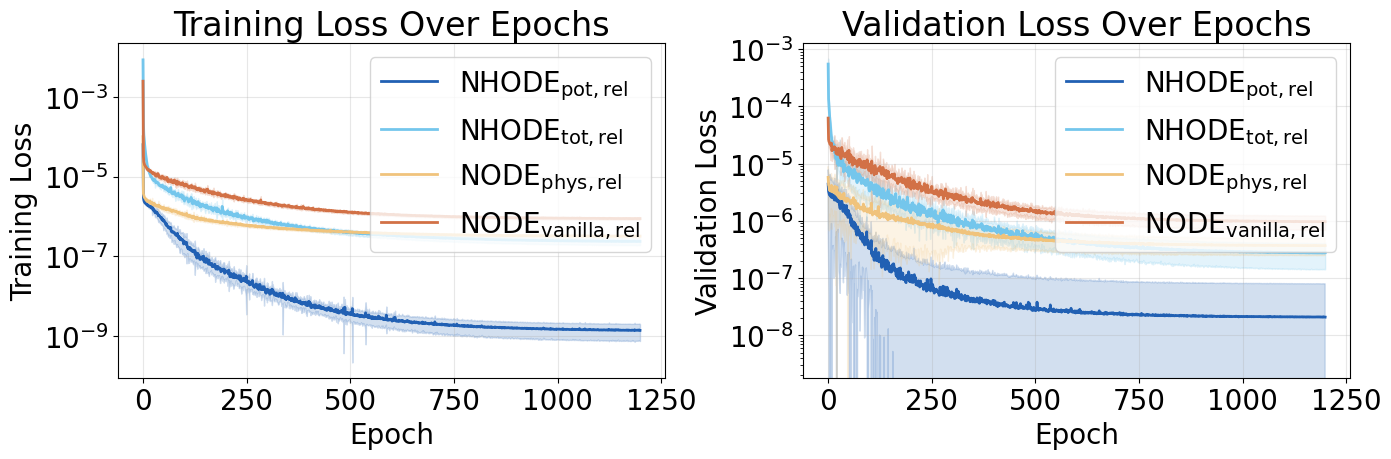

In [26]:
# Plot loss curves
plot_training_losses(
    method_to_paths,
    log_scale=True,
    save_path=None#Path("figures/training_losses.pdf"),
)

### 8.3 Error Over Time (Median with Percentiles)

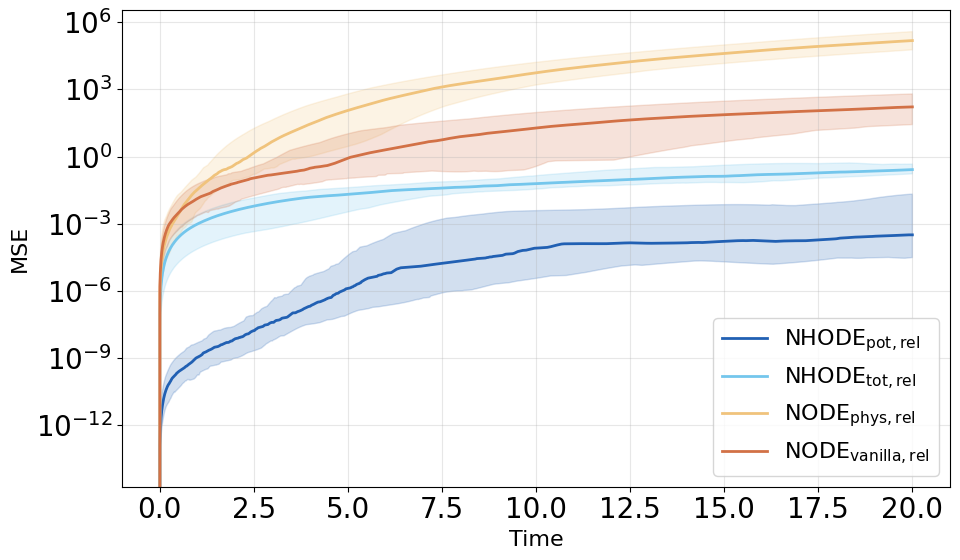

In [27]:
plot_error_over_time(
    all_metrics,
    timesteps=np.asarray(timesteps),
    use_median=True,
    log_scale=True,
    figsize=(10, 6),
    fontsize=16,
    save_path=None#Path("figures/error_over_time_median.pdf"),
)

### 8.4 Observed vs Unobserved vs Energy Error

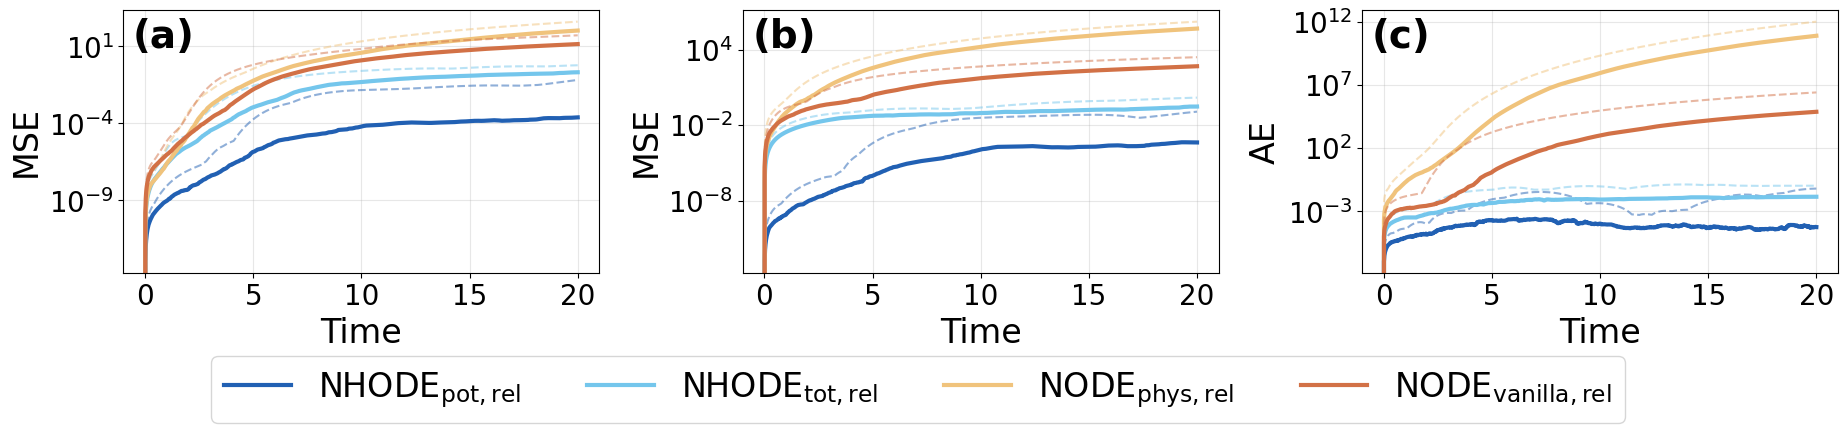

In [28]:
plot_observed_vs_unobserved_vs_energy_error(
    results=all_predictions,
    times=timesteps,
    system_params=system_params,
    figsize=(19, 4),
    fontsize=24,
    save_path=None#Path("figures/observed_unobserved_energy_error_v2.pdf"),
)

### 8.5 Error Over Time (Mean with Std)

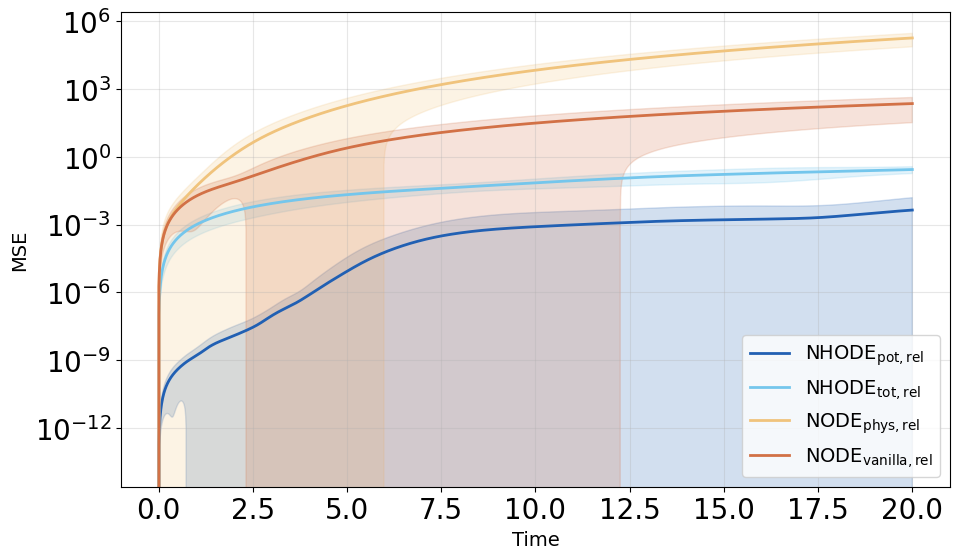

In [29]:
plot_error_over_time(
    all_metrics,
    timesteps=np.asarray(timesteps),
    use_median=False,
    log_scale=True,
    save_path=None#Path("figures/error_over_time_mean.png"),
)

### 8.6 2D Trajectory Visualization

/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_35059/555794634.py:107: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


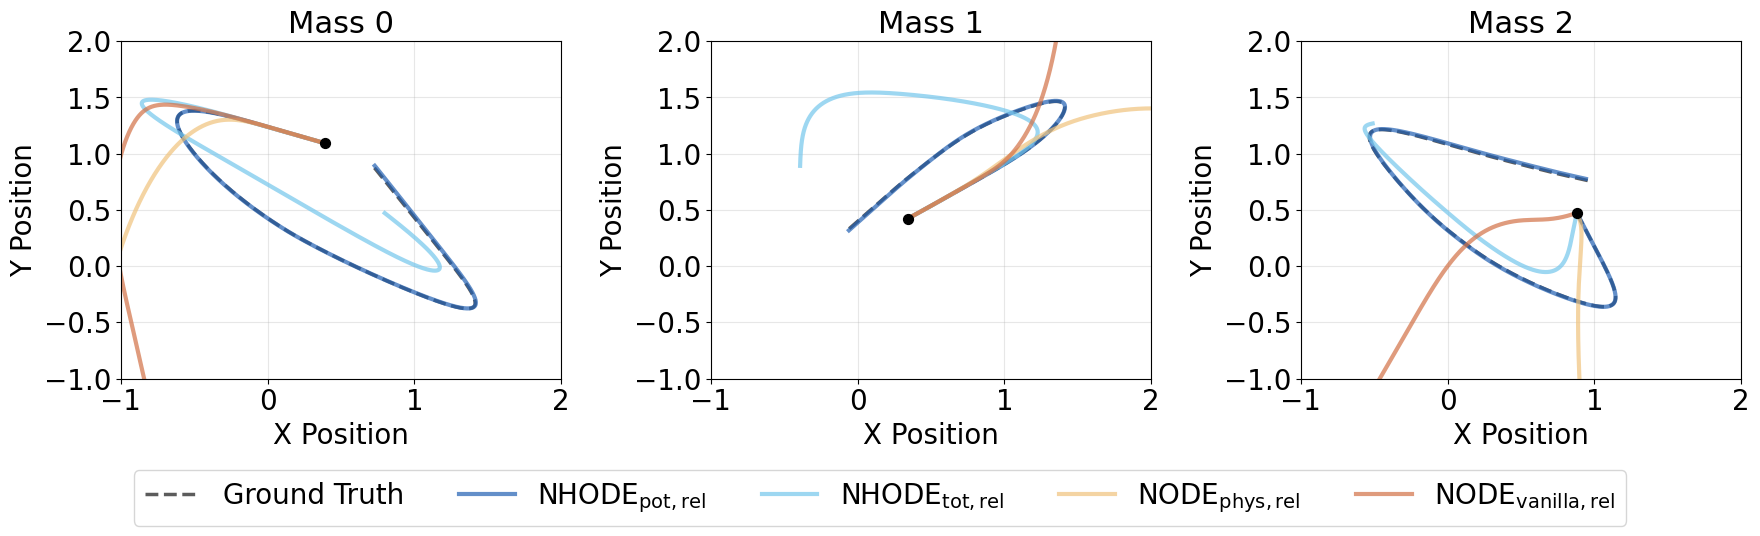

In [30]:
# Choose a test trajectory to visualize
ic_idx = 6

# Extract mean predictions for this IC
predictions_for_plot = {
    method: np.asarray(pred_data['mean_prediction'][ic_idx])
    for method, pred_data in all_predictions.items()
}

# Plot each mass

plot_2d_trajectory(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_for_plot,
    mass_idx=[0, 1, 2],
    figsize=(18, 5),
    fontsize=20,
    save_path=None,#Path(f"figures/2d_trajectory_xyz_component_comparison_{ic_idx}.pdf"),
    xlim=(-1.0, 2.0),
    ylim=(-1.0, 2.0)
    )
    

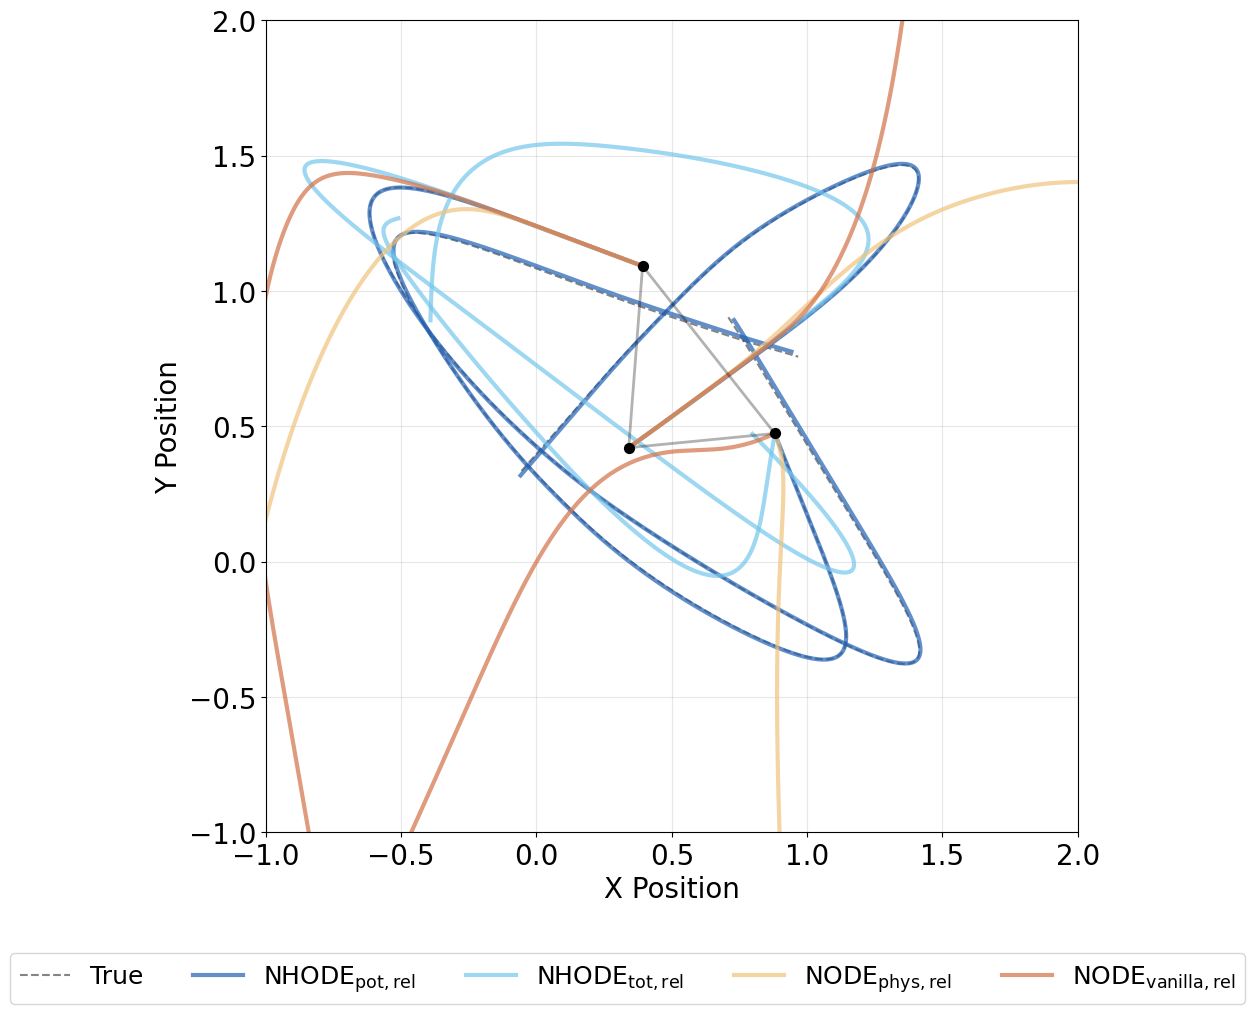

In [31]:
# Plot entire system
plot_2d_trajectory(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_for_plot, 
    mass_idx=None,
    save_path=None,#Path(f"figures/2d_system_configuration_ic{ic_idx}.pdf"),
    xlim=(-1.0, 2.0),
    ylim=(-1.0, 2.0),
    figsize=(10, 10),
    fontsize=18
)

### 8.7 1D Trajectory Comparison

In [32]:
import matplotlib.patches as mpatches

In [33]:
def plot_snapshot_grid(
    true_traj: np.ndarray,
    predictions_dict: Dict[str, np.ndarray],
    snapshot_indices: List[int],
    timesteps: np.ndarray,
    figsize: Tuple[float, float] = (20, 16),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
    xlim: Tuple[float, float] = (-0.5, 1.5),
    ylim: Tuple[float, float] = (-0.5, 1.5),
    wspace: float = 0.1,
    hspace: float = 0.1,
):
    """
    Plot a grid of system snapshots at specific timesteps.
    
    Rows = timesteps, Columns = True + each method.
    Each cell shows the 2D positions of the three masses with spring connections.
    
    Parameters
    ----------
    true_traj : array [T, 12]
        Ground truth trajectory
    predictions_dict : Dict[str, array [T, 12]]
        Dictionary mapping method name to predicted trajectory (mean over seeds)
    snapshot_indices : List[int]
        Timestep indices to show (rows)
    timesteps : array [T]
        Time array (for labeling)
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    fontsize : int
        Font size for labels
    xlim, ylim : tuple
        Axis limits for each subplot
    """
    methods_ordered = list(predictions_dict.keys())[::-1]  # Reverse for nicer plotting order
    n_rows = len(snapshot_indices)
    n_cols = 1 + len(methods_ordered)  # True + each method

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.subplots_adjust(wspace=wspace, hspace=hspace)
    # Mass colors (consistent across all subplots)
    mass_colors = ["#3D82C6", "#8FE7FF", "#E19A61"]  # red, green, blue
    spring_pairs = [(0, 1), (1, 2), (2, 0)]

    def draw_snapshot(ax, traj, t_idx, is_true=False, show_trail=True, trail_length=50):
        """Draw a single snapshot of the system at timestep t_idx."""
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

        # Draw fading tail (past trajectory), segmented for alpha gradient
        if show_trail and t_idx > 0:
            trail_start = max(0, t_idx - trail_length)
            n_trail = t_idx - trail_start
            n_segments = min(n_trail, 50)  # number of segments for fading effect

            for mass_i in range(3):
                xi = mass_i * 2
                yi = mass_i * 2 + 1

                # Split trail into segments, each progressively more opaque
                segment_indices = np.linspace(trail_start, t_idx, n_segments + 1, dtype=int)
                for seg in range(n_segments):
                    seg_alpha = 0.08 + 0.65 * (seg / n_segments)  # fade from 0.08 to 0.93
                    seg_lw = 0.8 + 10.0 * (seg / n_segments)       # thin to thick
                    i0, i1 = segment_indices[seg], segment_indices[seg + 1]
                    ax.plot(
                        traj[i0:i1+1, xi],
                        traj[i0:i1+1, yi],
                        color=mass_colors[mass_i],
                        alpha=seg_alpha,
                        linewidth=seg_lw,
                        solid_capstyle='round',
                        zorder=2,
                    )

        # Extract positions at this timestep
        pos = traj[t_idx, :6].reshape(3, 2)  # [3, 2]

        # Draw springs between masses
        for i, j in spring_pairs:
            ax.plot(
                [pos[i, 0], pos[j, 0]],
                [pos[i, 1], pos[j, 1]],
                color="#555555",
                linewidth=1.5,
                alpha=0.6,
                zorder=1,
            )

        # Draw masses
        for mass_i in range(3):
            ax.scatter(
                pos[mass_i, 0], pos[mass_i, 1],
                s=300,
                color=mass_colors[mass_i],
                edgecolors='black',
                linewidths=1.5,
                zorder=3,
            )

    # Column headers
    col_labels = ["True"] + [LABELS.get(m, m) for m in methods_ordered]
    for col_idx, label in enumerate(col_labels):
        axes[0, col_idx].set_title(label, fontsize=fontsize + 2, pad=10)#, fontweight='bold',)

    # Row labels (time)
    for row_idx, t_idx in enumerate(snapshot_indices):
        t_val = float(timesteps[t_idx])
        axes[row_idx, 0].set_ylabel(f"t = {t_val:.1f}", fontsize=fontsize, rotation=0,
                                     labelpad=45, va='center')

    # Fill in each cell
    for row_idx, t_idx in enumerate(snapshot_indices):
        # True trajectory
        draw_snapshot(axes[row_idx, 0], true_traj, t_idx, is_true=True, show_trail=True, trail_length=700)

        # Each method
        for col_idx, method in enumerate(methods_ordered):
            pred_traj = predictions_dict[method]
            draw_snapshot(axes[row_idx, col_idx + 1], pred_traj, t_idx, is_true=False, show_trail=True, trail_length=700)

    # Add a shared legend for mass colors
    labels = ["Mass 1", "Mass 2", "Mass 3 (unobserved)"]
    legend_elements = [
        plt.scatter([], [], s=150, color=mass_colors[i], edgecolors='black',
                    linewidths=1.5, label=labels[i])
        for i in range(3)
    ]
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=3,
        fontsize=fontsize + 2,
        bbox_to_anchor=(0.5, -0.06),
        framealpha=0.9,
    )

    #plt.suptitle("System Snapshots Over Time", fontsize=fontsize + 4, y=1.01)
    plt.tight_layout()

        # Draw a single black frame around the entire left (ground truth) column
    col0_bboxes = [axes[r, 0].get_position() for r in range(n_rows)]
    pad = 0 #0.004
    rx0 = min(b.x0 for b in col0_bboxes) - pad
    ry0 = min(b.y0 for b in col0_bboxes) - pad
    rx1 = max(b.x1 for b in col0_bboxes) + pad
    ry1 = max(b.y1 for b in col0_bboxes) + pad
    rect = mpatches.Rectangle(
        (rx0, ry0), rx1 - rx0, ry1 - ry0,
        linewidth=5,
        edgecolor='black',
        facecolor='none',
        transform=fig.transFigure,
        clip_on=False,
        zorder=10,
    )
    fig.add_artist(rect)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

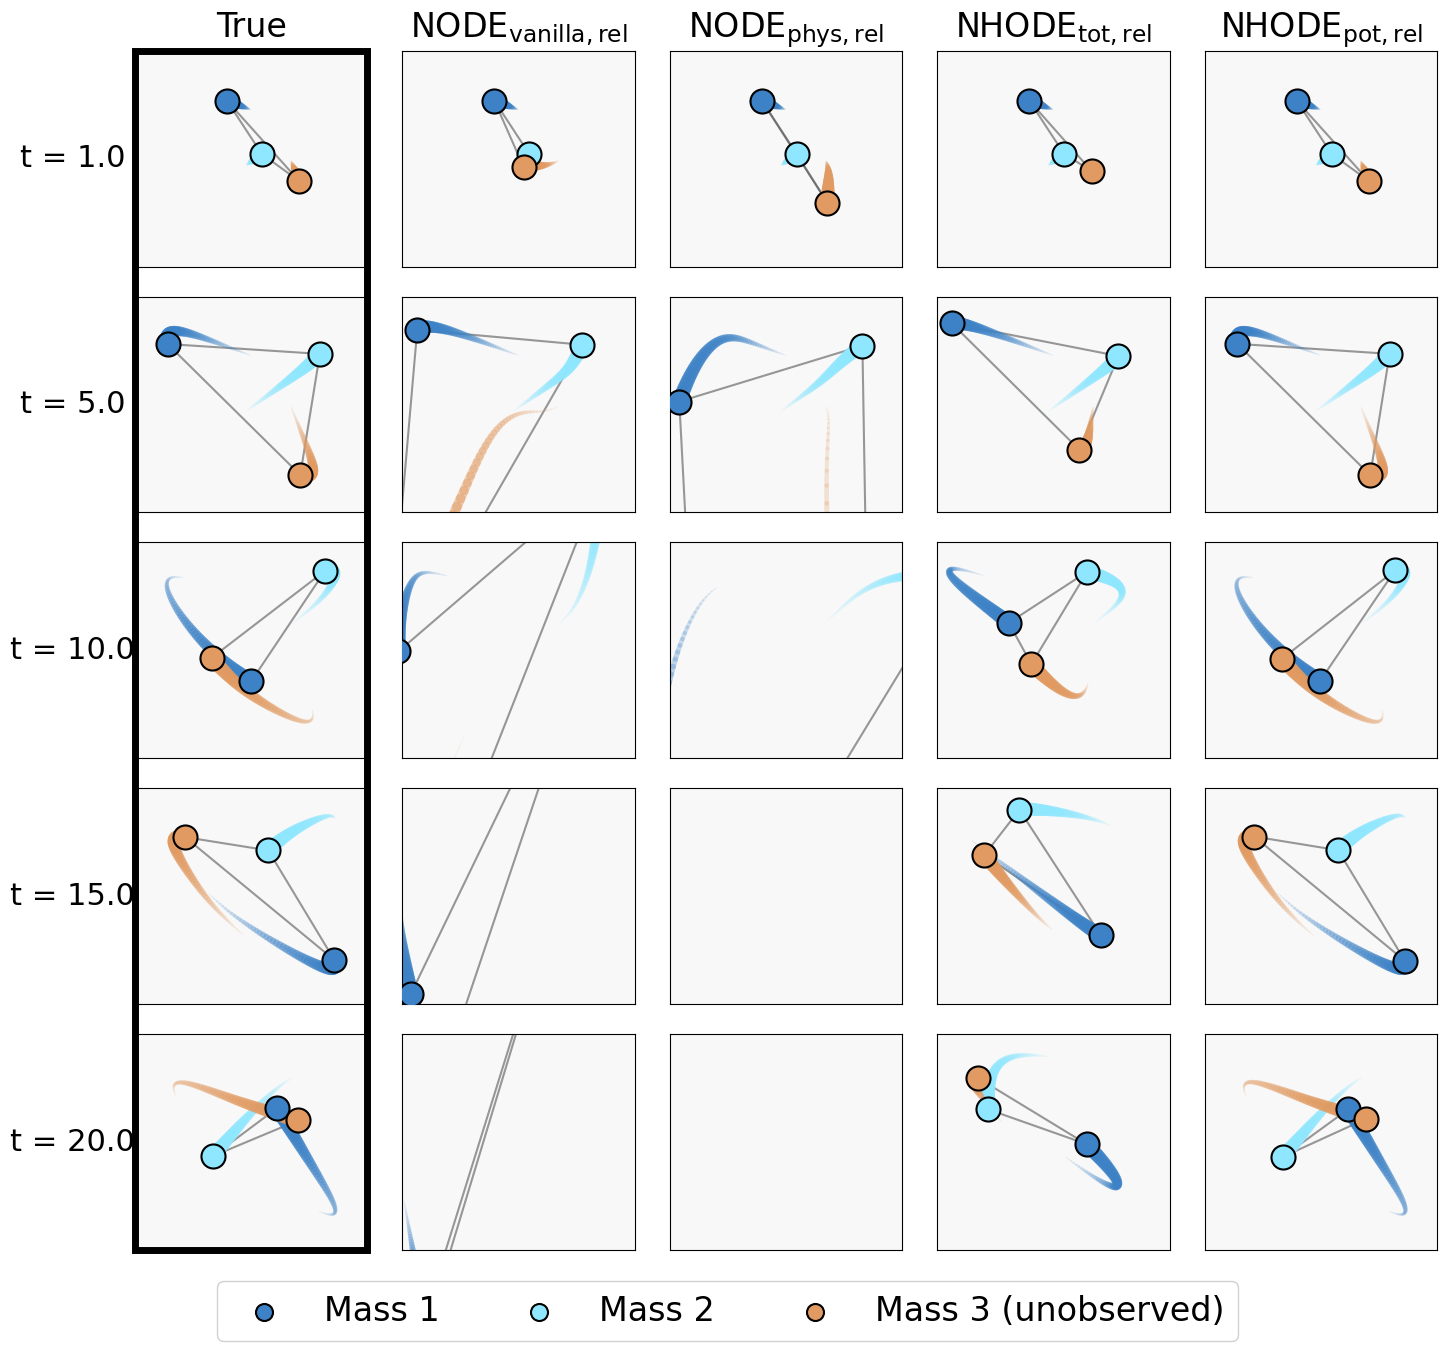

In [34]:
# Choose snapshot timestep indices (evenly spaced or hand-picked)
# snapshot_indices = [0, 500, 1000, 1500, 2000]
snapshot_indices = [100, 500, 1000, 1500, 2000]

# Use mean predictions for a single IC
ic_idx = 6
predictions_for_snapshot = {
    method: np.asarray(pred_data['mean_prediction'][ic_idx])
    for method, pred_data in all_predictions.items()
}

plot_snapshot_grid(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_for_snapshot,
    snapshot_indices=snapshot_indices,
    timesteps=np.asarray(timesteps),
    figsize=(15, 13),
    fontsize=22,
    xlim=(-1.0, 1.8),
    ylim=(-0.8, 1.8),
    save_path=None#Path("figures/snapshot_grid_without_t0_v2.pdf")
)

/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_35059/1619862899.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()   # stabilise positions before reading bboxes


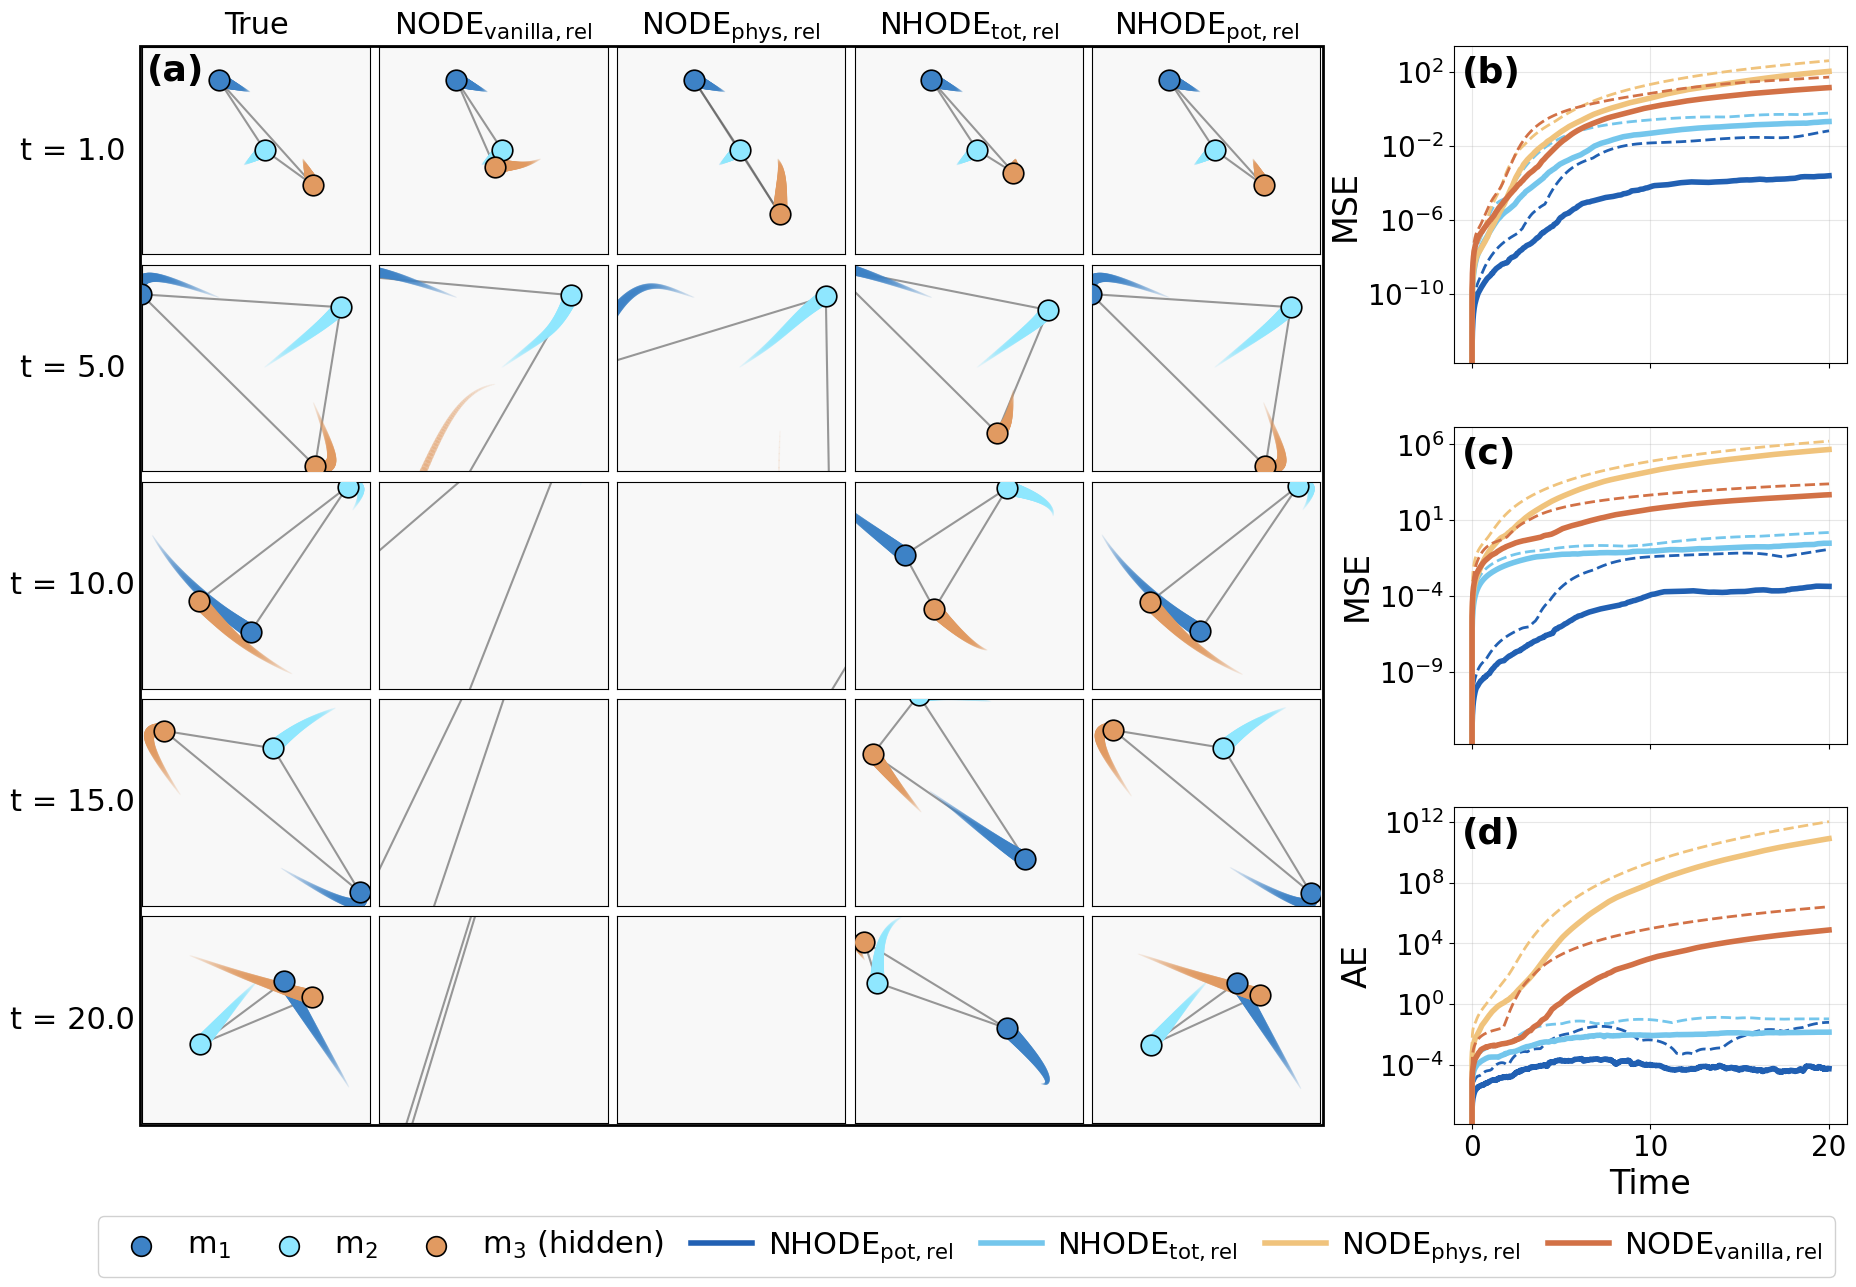

In [50]:
# ic_idx and snapshot_indices, predictions_for_snapshot already defined above
error_trajectories = {m: all_predictions[m] for m in predictions_for_plot}

plt.rcParams['font.size'] = 20

plot_combined_snapshot_and_errors(
    true_traj=np.asarray(true_trajectories[ic_idx]),
    predictions_dict=predictions_for_snapshot,
    all_trajectories=error_trajectories,
    snapshot_indices=snapshot_indices,
    timesteps=np.asarray(timesteps),
    system_params=system_params,
    figsize=(22, 14),
    snapshot_width_ratio=0.75,
    fontsize=24,
    xlim=(-0.6, 1.5),
    ylim=(-0.4, 1.5),
    trail_length=400,
    col_wspace=0.17,   # increase this for more room around right-column y-labels
    #save_path=Path('figures/combined_snapshot_and_errors.pdf'),
)

# Draw single snapshot

In [61]:
# Mass colors (consistent across all subplots)
mass_colors = ["#3D82C6", "#8FE7FF", "white"]  # red, green, blue"#E19A61"
spring_pairs = [(0, 1), (1, 2), (2, 0)]

def draw_snapshot(ax, traj, t_idx, xlim, ylim, is_true=False, show_trail=True, trail_length=50):
    """Draw a single snapshot of the system at timestep t_idx."""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_facecolor("#f8f8f8")
    ax.grid(True, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

    # Draw fading tail (past trajectory), segmented for alpha gradient
    if show_trail and t_idx > 0:
        trail_start = max(0, t_idx - trail_length)
        n_trail = t_idx - trail_start
        n_segments = min(n_trail, 50)  # number of segments for fading effect

        for mass_i in range(3):
            xi = mass_i * 2
            yi = mass_i * 2 + 1

            # Split trail into segments, each progressively more opaque
            segment_indices = np.linspace(trail_start, t_idx, n_segments + 1, dtype=int)
            for seg in range(n_segments):
                seg_alpha = 0.08 + 0.65 * (seg / n_segments)  # fade from 0.08 to 0.93
                seg_lw = 0.8 + 10.0 * (seg / n_segments)       # thin to thick
                i0, i1 = segment_indices[seg], segment_indices[seg + 1]
                ax.plot(
                    traj[i0:i1+1, xi],
                    traj[i0:i1+1, yi],
                    color=mass_colors[mass_i],
                    alpha=seg_alpha,
                    linewidth=seg_lw,
                    solid_capstyle='round',
                    zorder=2,
                )

    # Extract positions at this timestep
    pos = traj[t_idx, :6].reshape(3, 2)  # [3, 2]

    # Draw springs between masses
    for i, j in spring_pairs:
        ax.plot(
            [pos[i, 0], pos[j, 0]],
            [pos[i, 1], pos[j, 1]],
            color="#555555",
            linewidth=1.5,
            alpha=0.6,
            zorder=1,
        )

    # Draw masses
    for mass_i in range(2):
        ax.scatter(
            pos[mass_i, 0], pos[mass_i, 1],
            s=300,
            color=mass_colors[mass_i],
            edgecolors='black',
            linewidths=1.5,
            zorder=3,
        )
    
    ax.scatter(
        pos[2, 0], pos[2, 1],
        s=300,
        color=mass_colors[2],
        edgecolors='#777777',
        linewidths=1.5,
        linestyle='--',
        zorder=3,
        hatch='/////',
    )

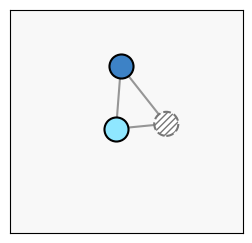

In [63]:
fig, ax = plt.subplots(figsize=(3, 3))

draw_snapshot(ax=ax, 
              traj=np.asarray(true_trajectories[ic_idx]), 
              t_idx=0, 
              xlim=(-0.8, 1.7),
              ylim=(-0.7, 1.7),
              is_true=True, 
              show_trail=True, 
              trail_length=700)

plt.savefig(Path("figures/snapshot_0_v3.pdf"), dpi=800)#, bbox_inches='tight')

### 8.8 Analyze Multiple Rollout Lengths

In [ ]:
def analyze_rollout_lengths(
    rollout_lengths: List[int],
    method_to_paths: Dict[str, List[Path]],
    y0_batch: jnp.ndarray,
    system_params: Params,
    t_final: float = 10.0,
    eval_dims: Optional[jnp.ndarray] = None,
) -> Dict[int, List[ErrorMetrics]]:
    """
    Evaluate cumulative errors for different rollout lengths.
    
    Returns
    -------
    results : Dict[int, List[ErrorMetrics]]
        Mapping from rollout length to list of metrics for each method
    """
    results = {}
    
    for n_steps in rollout_lengths:
        print(f"\n{'='*50}")
        print(f"Rollout length: {n_steps} steps")
        print(f"{'='*50}")
        
        # Create timesteps for this rollout length
        ts = jnp.linspace(0, t_final, n_steps)
        
        # Compute ground truth
        integrator_true = integrate_vector_field(
            ts, term=vector_field_triangular_nonlinear_mass_spring_2d
        )
        true_trajs = integrator_true(None, system_params, y0_batch)
        
        # Evaluate each method
        metrics_list = []
        for method, seed_dirs in method_to_paths.items():
            print(f"  {method}...", end=" ")
            key_local = jax.random.PRNGKey(42)
            metrics, _ = evaluate_method(
                method=method,
                seed_dirs=seed_dirs,
                y0_batch=y0_batch,
                true_trajectories=true_trajs,
                timesteps=ts,
                system_params=system_params,
                eval_dims=eval_dims,
                key=key_local,
            )
            metrics_list.append(metrics)
            print(f"cum_mean = {metrics.cum_mean:.6e}")
        
        results[n_steps] = metrics_list
    
    return results


def plot_cumulative_error_vs_rollout(
    results: Dict[int, List[ErrorMetrics]],
    figsize: Tuple[float, float] = (10, 6),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
):
    """
    Plot cumulative error as a function of rollout length.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Organize data by method
    rollout_lengths = sorted(results.keys())
    methods = [m.method for m in results[rollout_lengths[0]]]
    
    for method in methods:
        means = []
        stds = []
        
        for n_steps in rollout_lengths:
            metrics = next(m for m in results[n_steps] if m.method == method)
            means.append(metrics.cum_mean)
            stds.append(metrics.cum_std)
        
        means = np.array(means)
        stds = np.array(stds)
        
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        ax.plot(rollout_lengths, means, 'o-', label=label, color=color, linewidth=2, markersize=8)
        ax.fill_between(rollout_lengths, means - stds, means + stds, alpha=0.2, color=color)
    
    ax.set_xlabel('Number of Timesteps', fontsize=fontsize)
    ax.set_ylabel('Cumulative MSE', fontsize=fontsize)
    ax.set_title('Cumulative Error vs Rollout Length', fontsize=fontsize+2)
    ax.legend(fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [ ]:
# Analyze different rollout lengths
rollout_lengths = [100, 250, 500, 1000, 2000]

rollout_results = analyze_rollout_lengths(
    rollout_lengths=rollout_lengths,
    method_to_paths=method_to_paths,
    y0_batch=y0_batch,
    system_params=system_params,
    t_final=T_FINAL,
    eval_dims=eval_dims,
)

# Plot results
plot_cumulative_error_vs_rollout(
    rollout_results,
    save_path=None#Path("figures/cumulative_error_vs_rollout.png"),
)


Rollout length: 100 steps
  hnn_pot... cum_mean = 1.271007e-03
  hnn_tot... cum_mean = 3.486366e-01

Rollout length: 250 steps
  hnn_pot... 

KeyboardInterrupt: 

## 9. Custom Analysis

Add your own analysis cells here!